In [2]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV, train_test_split

In [3]:
seed = 1234
np.random.seed(seed)

## Data Loading

In [4]:
data = pd.read_csv('./data/training.csv')
test_data = pd.read_csv('./data/public_processed.csv')

In [44]:
group_map = pd.read_csv('./preprocess_data/output.txt', header=None, delimiter=' ')
group_map_dict = group_map.set_index(0)[1].to_dict()

## Data Analysis

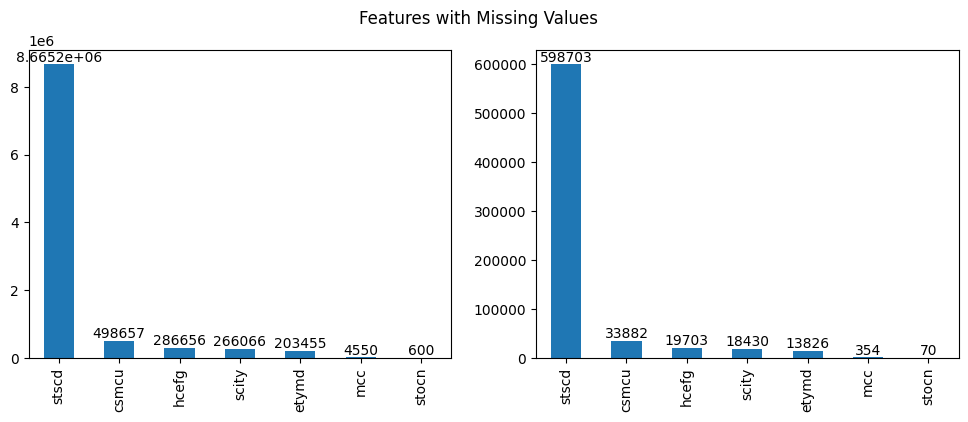

In [5]:
plt.figure(figsize=(12, 4))

for i, tmp_data in enumerate([data, test_data]):
    plt.subplot(1, 2, i + 1)
    null_counts = tmp_data.isnull().sum().sort_values(ascending=False)
    ax = null_counts[null_counts > 0].plot(kind='bar')
    ax.bar_label(ax.containers[0])

plt.suptitle('Features with Missing Values')
plt.show()

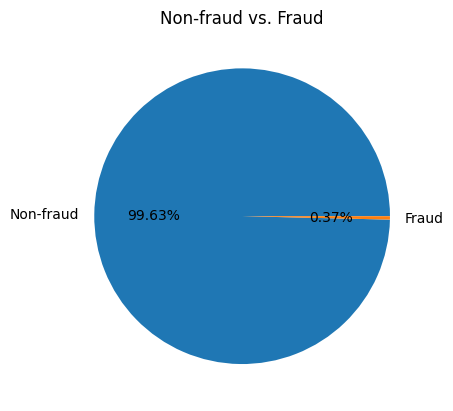

In [6]:
ax = data['label'].value_counts().plot(
    kind='pie',
    labels=['Non-fraud', 'Fraud'],
    autopct='%.2f%%'
)
plt.ylabel('')
plt.title('Non-fraud vs. Fraud')
plt.show()

In [8]:
def pretty_desc(data):
    display(pd.DataFrame(data.describe()).T)

In [26]:
pretty_desc(data['conam'])
pretty_desc(data[data['label'] == 0]['conam'])
pretty_desc(data[data['label'] == 1]['conam'])

,count,mean,std,min,25%,50%,75%,max
conam,8688526.0,1418.676495,9518.751404,0.0,105.0,315.0,900.0,5051970.0


,count,mean,std,min,25%,50%,75%,max
conam,8656497.0,1405.57253,9475.443498,0.0,105.0,314.0,899.0,5051970.0


,count,mean,std,min,25%,50%,75%,max
conam,32029.0,4960.293053,17330.631764,0.0,100.0,1249.95,2990.0,611265.6


In [25]:
count = (data['flam1'] == 0).sum()
print(f'#cases that flam1 == 0: {count}')

pretty_desc(data['flam1'] / data['conam'])

#cases that flam1 == 0: 291395


,count,mean,std,min,25%,50%,75%,max
0,8402835.0,0.999269,0.02703,0.0,0.998483,1.0,1.001275,1.639344


In [36]:
def show_max_day(data):
    print(f'Max day: {data["locdt"].max()}')

show_max_day(data)
show_max_day(test_data)

Max day: 55
Max day: 59


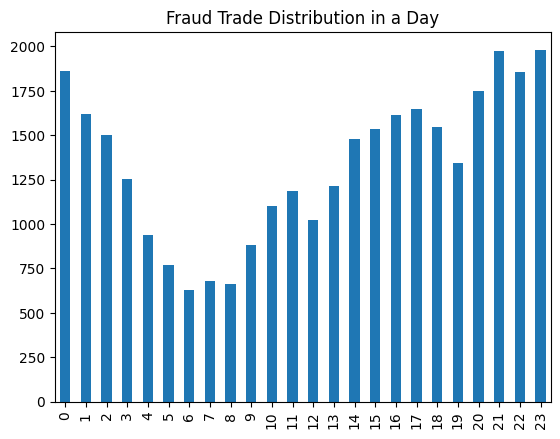

In [84]:
fraud_trades = data[data['label'] == 1]
ax = fraud_trades['loctm'] \
    .value_counts(bins=range(0, 250000, 10000)) \
    .sort_index() \
    .plot(kind='bar')
ax.set_xticklabels(range(0, 24))
plt.title('Fraud Trade Distribution in a Day')
plt.show()

In [10]:
num_feat = [
    'locdt',
    'loctm',
    'conam',
    'iterm',
    'flam1',
    'csmam',
]
cat_feat = [
    col for col in data.columns
    if col not in num_feat and col != 'label'
]

In [11]:
print('Unique Count:')
for feat in cat_feat:
    count = data[feat].nunique()
    print(f'- {feat}: {count}')

Unique Count:
- txkey: 8688526
- chid: 482667
- cano: 618898
- contp: 7
- etymd: 10
- mchno: 163797
- acqic: 8334
- mcc: 459
- ecfg: 2
- insfg: 2
- bnsfg: 2
- stocn: 122
- scity: 12003
- stscd: 5
- ovrlt: 2
- flbmk: 2
- hcefg: 11
- csmcu: 79
- flg_3dsmk: 2


## Data Preprocessing
- Deal with Missing Data
    - fill them with something or remove samples with missing data
    - missed data are all categorical data
    - perhaps N/A should be seen as a category
- Encoding
    - categorical -> one-hot
        - feature with numerous categories is not suitable for one-hot encoding
        - decision tree doesn't require one-hot encoding
    - numerical -> normalization (0 ~ 1)
        - decision tree doesn't require normalization
- Data Balancing
- Feature Extraction
    1. column removal by intuition
    2. column removal with PCA
    3. column removal by intuition + PCA
    4. create meaningful columns
        - scity -> portion of fraud trade in that city?
- Deal with Time Data

In [45]:
# by intuition
removed_feat = [
    'txkey',  # 交易序號
    'cano',   # 卡號
    'mchno',  # 特店代號
    'acqic',  # 收單行代碼
    'csmam',  # 消費地金額

    # 'chid'
]

processed_data = data.drop(columns=removed_feat)
# processed_data = processed_data.dropna()  # drop rows with N/A value
processed_data['chid'] = processed_data['chid'].map(group_map_dict)

labels = data['label']
processed_data = processed_data.drop(columns='label')

In [47]:
chid_uniq_cat_before = data['chid'].nunique()
chid_uniq_cat_after = processed_data['chid'].nunique()

print(f'#unique customers: {chid_uniq_cat_before} -> {chid_uniq_cat_after}')

#unique customers: 482667 -> 482662


In [48]:
test_txkey = test_data['txkey']
test_data = test_data.drop(columns=removed_feat)
test_data['chid'] = test_data['chid'].map(group_map_dict)

In [56]:
def loctm_to_sec(loctm):
    hr = loctm // 10000
    mn = (loctm // 100) % 100
    sc = loctm % 100
    return hr * 3600 + mn * 60 + sc

processed_data['loctm'] = processed_data['loctm'].map(loctm_to_sec)

## Model Construction
- random forest
- SVM
- Logistic Regression
- ~~XGBoost~~ LightGBM

In [17]:
lgb_classifier = lgb.LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    device='gpu'
)

## Training & Validation
- 800-fold cross validation

In [18]:
left_cat_feat = [
    feat for feat in cat_feat
    if feat not in removed_feat
]

X_train, X_valid, y_train, y_valid = train_test_split(processed_data, labels, test_size=0.3)

lgb_classifier.fit(
    X_train, y_train,
    categorical_feature=left_cat_feat,
    callbacks=[lgb.early_stopping(5)],
    eval_set=[(X_valid, y_valid)],
    eval_metric='binary_logloss',
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 22383, number of negative: 6059585
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1458
[LightGBM] [Info] Number of data points in the train set: 6081968, number of used features: 19


[LightGBM] [Fatal] bin size 269 cannot run on GPU


LightGBMError: bin size 269 cannot run on GPU

In [ ]:
# params = {
#     'num_leaves': [31, 41, 51],
#     'learning_rate': [0.1, 0.2, 0.3],
#     'n_estimators': [2, 50, 100],
# }
# grid_search = GridSearchCV(lgb_classifier, params, cv=14)

# grid_search.fit(
#     data, labels,
#     eval_metric='auc,binary_logloss',
#     categorical_features=cat_feat,
#     callbacks=[lgb.early_stopping(5)]
# )

# print(f'Best params: {grid_search.best_params_}')

## Prediction

In [ ]:
y_pred = lgb_classifier.predict(test_data)
# y_pred = grid_search.predict(test_data)
res = {
    'txkey': test_txkey,
    'label': y_pred
}

pd.DataFrame(res).to_csv('preds.csv', index=False)

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
